# Assignment: K Nearest Neighbors on Wine Classification

## Objective

In this assignment, you will use K Nearest Neighbors (KNN) to classify wine samples into different wine classes.

You will practice:

- Loading and inspecting a classification dataset
- Training KNN without scaling
- Training KNN with scaling
- Choosing the value of \(K\)
- Comparing distance metrics
- Using distance-weighted KNN
- Using KNN imputation for missing values

This is a lightweight assignment. Focus on correct implementation and clear interpretation.

## Dataset

We will use the built-in Wine dataset from scikit-learn.

The dataset contains chemical measurements of wine samples. The target is the wine class.

This is a **multiclass classification problem**.

## 1. Setup

Run the install cell only if any package is missing.

In [1]:
# Run this only if required.
# %pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the Dataset

Load the Wine dataset using `load_wine(as_frame=True)`.

In [3]:
# TODO: Load the wine dataset.
# Hint: use load_wine(as_frame=True)

wine = load_wine(as_frame=True)
df = wine.frame
df.head()





,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# TODO: Create X and y.
# Hint:
# - X should contain the feature DataFrame.
# - y should contain the target values.

Y = df['target']
X = df.drop(columns=['target'])


In [5]:
# TODO: Display the first 5 rows of X and check the shape of X.
print(X.head())
print(Y.head())
print(X.shape)
print(Y.shape)


   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

## 3. Check Class Distribution

Before training a classification model, check how many samples belong to each class.

In [6]:
# TODO: Show count and percentage distribution of y.
# Hint: use value_counts() and value_counts(normalize=True)
print(Y.value_counts())
print(Y.value_counts(normalize=True))

target
1    71
0    59
2    48
Name: count, dtype: int64
target
1    0.398876
0    0.331461
2    0.269663
Name: proportion, dtype: float64


### Question 1

Is the Wine dataset heavily imbalanced? Why or why not?

Write your answer here:

- No, there is a fairly well dsitribution for each target class

## 4. Train-Test Split

Use a stratified split so each wine class keeps a similar proportion in train and test data.

In [7]:
# TODO: Split X and y into training and test sets.
# Use test_size=0.2, random_state=RANDOM_STATE, and stratify=y.
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE, stratify=Y)

In [8]:
# TODO: Check class distribution in y_train and y_test.
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(target
 1    0.401408
 0    0.330986
 2    0.267606
 Name: proportion, dtype: float64,
 target
 1    0.388889
 0    0.333333
 2    0.277778
 Name: proportion, dtype: float64)

## 5. Baseline KNN Without Scaling

Train a KNN classifier without scaling.

Use:

```python
KNeighborsClassifier(n_neighbors=5)
```

This model is intentionally incomplete from a best-practice point of view. We will compare it with scaled KNN next.

In [9]:
# TODO: Create and train a KNN model without scaling.
# TODO: Predict on X_test.
# Store predictions in y_pred_no_scaling.
knn_clf = Pipeline([
    ("knn", KNeighborsClassifier())
])
knn_clf.fit(X_train, y_train)
y_pred_no_scaling = knn_clf.predict(X_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.77      0.71      0.74        14
           2       0.64      0.70      0.67        10

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.81      0.81      0.81        36



Text(66.91216362847221, 0.5, 'Actual')

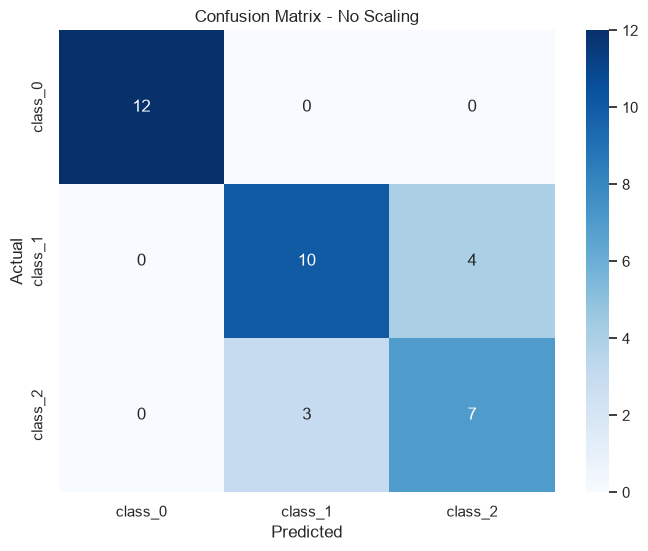

In [10]:
# TODO: Print accuracy and classification report for the no-scaling model.
# TODO: Plot a confusion matrix.
print(classification_report(y_test, y_pred_no_scaling))
confusion_matrix_no_scaling = confusion_matrix(y_test, y_pred_no_scaling)
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix - No Scaling")
sns.heatmap(confusion_matrix_no_scaling, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")

## 6. KNN With Scaling

KNN is distance-based, so feature scaling is very important.

For standard scaling:

\[
x_j^{scaled}=\frac{x_j-\mu_j}{\sigma_j}
\]

Use a pipeline:

```text
StandardScaler -> KNeighborsClassifier
```

In [11]:
# TODO: Create a pipeline with StandardScaler and KNeighborsClassifier(n_neighbors=5).
# TODO: Train the pipeline on X_train and y_train.
# TODO: Predict on X_test.
# Store predictions in y_pred_scaled.
knn_clf_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_clf_scaled.fit(X_train, y_train)
y_pred_scaled = knn_clf_scaled.predict(X_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



Text(66.91216362847221, 0.5, 'Actual')

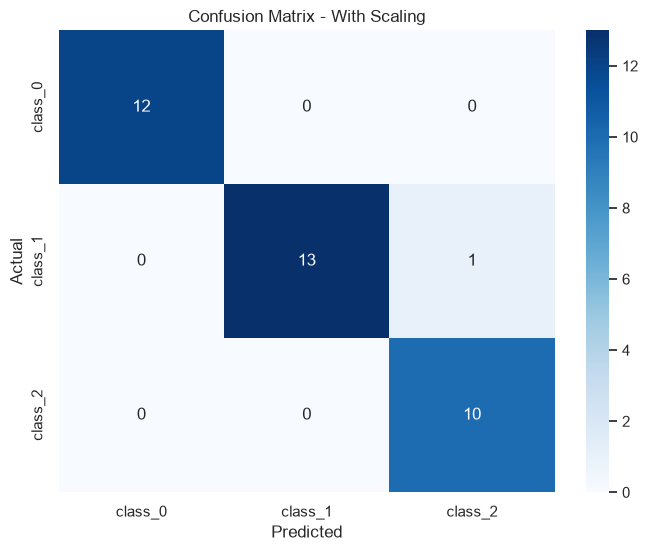

In [12]:
# TODO: Print accuracy and classification report for the scaled model.
# TODO: Plot a confusion matrix.
print(classification_report(y_test, y_pred_scaled))
confusion_matrix_scaled = confusion_matrix(y_test, y_pred_scaled)
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix - With Scaling")
sns.heatmap(confusion_matrix_scaled, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")    

### Question 2

Did scaling improve the model performance? Explain why scaling matters for KNN.

Write your answer here:

- Yes, scaling helped. Scaling is better for KNN as KNN is distance based

## 7. Choose the Value of \(K\)

Try multiple values of \(K\):

```python
[1, 3, 5, 7, 9, 11, 15]
```

Use cross-validation on the training data.

In [13]:
k_values = [1, 3, 5, 7, 9, 11, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# TODO: For each K, create a scaled KNN pipeline.
# TODO: Use cross_val_score on training data.
# TODO: Store mean CV accuracy for each K in a DataFrame.
mean_cv_accuracies = []
for k in k_values:
    knn_clf_scaled = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    cv_scores = cross_val_score(knn_clf_scaled, X_train, y_train, cv=cv, scoring='accuracy')
    mean_cv_accuracy = np.mean(cv_scores)
    mean_cv_accuracies.append(mean_cv_accuracy)
    print(f"K={k}: Mean CV Accuracy={mean_cv_accuracy:.4f}")

K=1: Mean CV Accuracy=0.9227
K=3: Mean CV Accuracy=0.9369
K=5: Mean CV Accuracy=0.9507
K=7: Mean CV Accuracy=0.9579
K=9: Mean CV Accuracy=0.9507
K=11: Mean CV Accuracy=0.9579
K=15: Mean CV Accuracy=0.9579


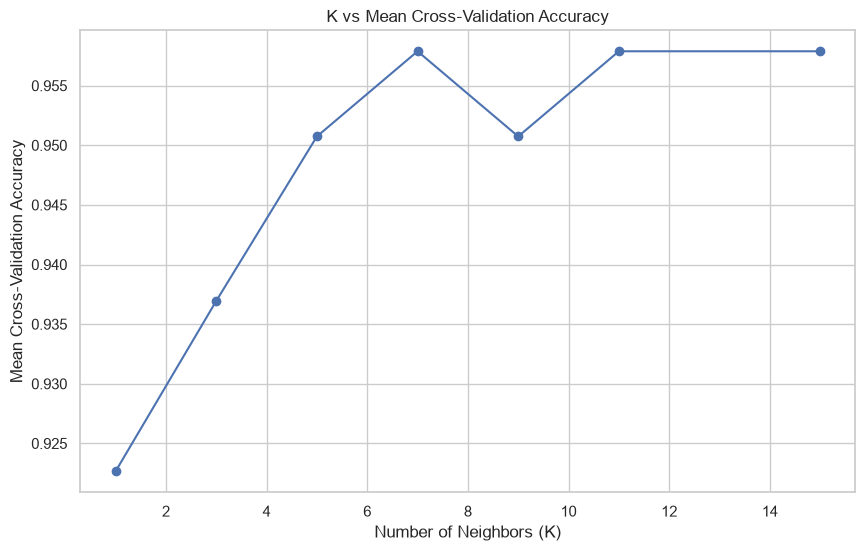

In [14]:
# TODO: Plot K vs cross-validation accuracy.
# TODO: Choose the best K based on CV accuracy.
# Store your selected value in best_k.
plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_cv_accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("K vs Mean Cross-Validation Accuracy")

best_k = 7


### Question 3

What can happen when \(K=1\)? What can happen when \(K\) is very large?

Write your answer here:

- k = 1 is very sensitive to noise and outliers and can also overfit wheras, k=100 can cause undefitting.

## 8. Compare Distance Metrics

Compare KNN with:

- Euclidean distance
- Manhattan distance

Use your selected `best_k` and scaling.

In [15]:
# TODO: Compare metric="euclidean" and metric="manhattan" using cross-validation.
# TODO: Store results in a DataFrame.

metric_results = []
for metric in ["euclidean", "manhattan"]:
    knn_clf_scaled = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=best_k, metric=metric))
    ])
    cv_scores = cross_val_score(knn_clf_scaled, X_train, y_train, cv=cv, scoring='accuracy')
    mean_cv_accuracy = np.mean(cv_scores)
    metric_results.append({"Metric": metric, "Mean CV Accuracy": mean_cv_accuracy})
    print(f"Metric={metric}: Mean CV Accuracy={mean_cv_accuracy:.4f}")
    metric_results_df = pd.DataFrame(metric_results)

metric_results_df

Metric=euclidean: Mean CV Accuracy=0.9579
Metric=manhattan: Mean CV Accuracy=0.9788


,Metric,Mean CV Accuracy
0,euclidean,0.957882
1,manhattan,0.978818


### Question 4

Which distance metric performed better? Was the difference large or small?

Write your answer here:

- Manhattan distance performed better here helping achieve a accuracy of 97.8% which is an improvemne tof 2% approx.

## 9. Distance-Weighted KNN

In normal KNN, all neighbors vote equally.

In distance-weighted KNN, closer neighbors get more importance.

Compare:

```python
weights="uniform"
weights="distance"
```

In [16]:
# TODO: Compare weights="uniform" and weights="distance" using cross-validation.
# Use best_k, scaling, and your preferred distance metric.
# Store results in a DataFrame.
weights = ["uniform", "distance"]
weight_results = []
for weight in weights:
    knn_clf_scaled = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=best_k, metric="manhattan", weights=weight))
    ])
    cv_scores = cross_val_score(knn_clf_scaled, X_train, y_train, cv=cv, scoring='accuracy')
    mean_cv_accuracy = np.mean(cv_scores)
    weight_results.append({"Weight": weight, "Mean CV Accuracy": mean_cv_accuracy})
    print(f"Weight={weight}: Mean CV Accuracy={mean_cv_accuracy:.4f}")
   

weight_results_df = pd.DataFrame(weight_results)
weight_results_df

Weight=uniform: Mean CV Accuracy=0.9788
Weight=distance: Mean CV Accuracy=0.9788


,Weight,Mean CV Accuracy
0,uniform,0.978818
1,distance,0.978818


### Question 5

When might distance-weighted KNN be better than uniform voting?

Write your answer here:

- When nearby information is much more important than farther way neighbors

## 10. Final KNN Model

Train your final model using:

- Scaling
- Selected \(K\)
- Selected distance metric
- Selected weighting method

Evaluate on the test data only once after making your choices.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Mean CV Accuracy=0.9788


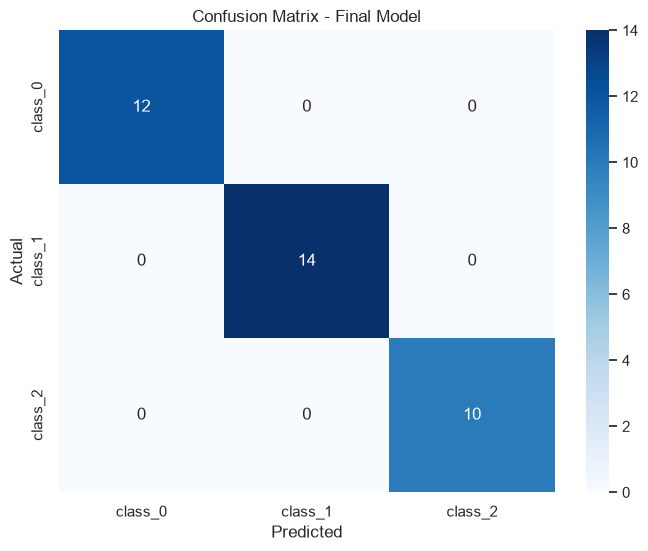

In [18]:
# TODO: Create your final KNN pipeline.
# TODO: Train it on X_train and y_train.
# TODO: Predict on X_test.
# TODO: Report accuracy, classification report, and confusion matrix.

knn_final_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k, metric="manhattan", weights="distance"))
])  
knn_final_clf.fit(X_train, y_train)
y_pred_final = knn_final_clf.predict(X_test)
print(classification_report(y_test, y_pred_final))
confusion_matrix_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix - Final Model")
sns.heatmap(confusion_matrix_final, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")

cv_scores = cross_val_score(knn_clf_scaled, X_train, y_train, cv=cv, scoring='accuracy')
mean_cv_accuracy = np.mean(cv_scores)
print(f"Mean CV Accuracy={mean_cv_accuracy:.4f}")

## 11. Mini Task: KNN Imputation

KNN can also be used to fill missing values using similar rows.

In this section, you will create a small amount of missing data and use `KNNImputer`.

In [ ]:
X_missing = X.copy()

# This randomly makes around 5% of values missing.
rng = np.random.default_rng(RANDOM_STATE)
missing_mask = rng.random(X_missing.shape) < 0.05
X_missing = X_missing.mask(missing_mask)

# Check missing values per column.
X_missing.isna().sum().sort_values(ascending=False).head(10)

In [ ]:
# TODO: Use KNNImputer to fill missing values.
# Hint:
# - Create KNNImputer with a small number of neighbors, for example 3 or 5.
# - Fit and transform X_missing.
# - Convert the result back into a DataFrame with the same column names.

raise NotImplementedError("Apply KNN imputation")

In [ ]:
# TODO: Verify that there are no missing values left after imputation.

raise NotImplementedError("Check missing values after KNN imputation")

### Question 6

Why can scaling matter before KNN imputation?

Write your answer here:

-

## 12. Final Reflection Questions

Answer briefly.

### Question 7

What does a trained KNN model store?

Answer:

-

### Question 8

Why can KNN become slow when the dataset becomes very large?

Answer:

-

### Question 9

Which final KNN configuration did you choose, and why?

Mention:

- \(K\)
- Distance metric
- Uniform or distance-weighted voting
- Final test accuracy

Answer:

-

## Submission Checklist

Submit your completed notebook with:

- All code cells executed
- K comparison table or plot
- Distance metric comparison
- Uniform vs distance-weighted comparison
- Final model evaluation
- KNN imputation result
- Answers to all questions